# Ablation Study: Zero-shot vs. Fine-tuned NER

**Цель:** сравнить три точки измерения по одним и тем же метрикам:

| Модель | Описание |
|---|---|
| **A — Zero-shot** | RuBERT «из коробки», без какого-либо дообучения |
| **B — Fine-tuned (val)** | Дообученная модель, тест на валидационной выборке (in-domain) |
| **C — Fine-tuned (external)** | Та же дообученная модель, тест на внешнем датасете (out-of-domain) |

**Что даёт это сравнение:**
- `B − A` → вклад fine-tuning на знакомом домене
- `C − A` → вклад fine-tuning на незнакомом домене
- `C − B` → просадка при смене домена (domain shift)
- Если `C ≈ A` → fine-tuning не помог обобщению, только запомнил обучающий корпус

**Метрики (все по теории):**
- Overall / per-entity F1 — стандарт seqeval
- ECR — Entity Coverage Ratio (Fu et al., 2020)
- CP-UNE / CUP-UNE — метрики на невидимых сущностях (Shaheen et al., 2023)
- ECE — Expected Calibration Error (Lin et al., 2020)
- Confusion matrix по типам сущностей


In [ ]:
!pip install -q transformers datasets seqeval openpyxl accelerate matplotlib scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 833.9 kB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
!pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.9 MB/s eta 0:00:00


Импорты и константы

In [ ]:
import zipfile, os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from collections import defaultdict
from google.colab import files as colab_files
from datasets import Dataset
from transformers import (AutoTokenizer, AutoModelForTokenClassification,
                          Trainer, TrainingArguments, pipeline)
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix, ConfusionMatrixDisplay
import evaluate

seqeval = evaluate.load('seqeval')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Лейблы — фиксированы для всего ноутбука
LABEL_LIST = ['O', 'B-LOC', 'I-LOC', 'B-PERS', 'I-PERS', 'B-NORP', 'I-NORP']
ENTITY_TYPES = ['LOC', 'PERS', 'NORP']
label2id = {l: i for i, l in enumerate(LABEL_LIST)}
id2label = {i: l for l, i in label2id.items()}

BASE_MODEL = 'DeepPavlov/rubert-base-cased-conversational'

print(f'Устройство: {device}')
print(f'Лейблы: {LABEL_LIST}')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Устройство: cuda
Лейблы: ['O', 'B-LOC', 'I-LOC', 'B-PERS', 'I-PERS', 'B-NORP', 'I-NORP']


Вспомогательные функции

In [ ]:
# Фиксим BIO
def fix_bio(labels):
    fixed, fixes = labels.copy(), 0
    for i in range(1, len(labels)):
        curr = labels[i]
        if not curr.startswith('I-') or labels[i-1] != 'O':
            continue
        etype = curr.split('-')[1]
        for j in range(i - 2, -1, -1):
            if labels[j] in (f'B-{etype}', f'I-{etype}'):
                for k in range(j + 1, i):
                    if labels[k] == 'O':
                        fixed[k] = f'I-{etype}'
                        fixes += 1
                break
            elif labels[j] != 'O':
                break
    return fixed, fixes

# Список предложений
def build_sentences(df):
    sents = []
    for _, grp in df.groupby('Sentence_ID', sort=True):
        sents.append({'tokens': grp['Token'].tolist(),
                      'ner_tags': grp['Label'].tolist()})
    return sents

# Токенизация
def make_tokenize_fn(tok):
    def tokenize_and_align(examples):
        tokenized = tok(examples['tokens'], truncation=True,
                        is_split_into_words=True,
                        padding='max_length', max_length=128)
        all_labels = []
        for i, label_seq in enumerate(examples['ner_tags']):
            word_ids = tokenized.word_ids(batch_index=i)
            prev_word, label_ids = None, []
            for wid in word_ids:
                if wid is None:
                    label_ids.append(-100)
                elif wid != prev_word:
                    label_ids.append(label2id.get(label_seq[wid], 0))
                else:
                    label_ids.append(-100)
                prev_word = wid
            all_labels.append(label_ids)
        tokenized['labels'] = all_labels
        return tokenized
    return tokenize_and_align

def to_hf_ds(sents, tokenize_fn):
    ds = Dataset.from_dict({'tokens':   [s['tokens']   for s in sents],
                             'ner_tags': [s['ner_tags'] for s in sents]})
    ds = ds.map(tokenize_fn, batched=True)
    keep = ['input_ids', 'attention_mask', 'token_type_ids', 'labels']
    return ds.remove_columns([c for c in ds.column_names if c not in keep])

# Декодирование предсказаний
def decode_preds(raw_preds, raw_labels):
    preds = np.argmax(raw_preds, axis=2)
    true_preds, true_labels = [], []
    for pred_seq, label_seq in zip(preds, raw_labels):
        tp, tl = [], []
        for p_id, l_id in zip(pred_seq, label_seq):
            if l_id != -100:
                tp.append(id2label[p_id])
                tl.append(id2label[l_id])
        true_preds.append(tp)
        true_labels.append(tl)
    return true_preds, true_labels

# Извлечение span-ов для ECR
def extract_spans(sentences):
    spans = []
    for sent in sentences:
        span, etype = [], None
        for tok, lbl in zip(sent['tokens'], sent['ner_tags']):
            if lbl.startswith('B-'):
                if span: spans.append((' '.join(span).lower(), etype))
                span, etype = [tok], lbl.split('-')[1]
            elif lbl.startswith('I-') and span:
                span.append(tok)
            else:
                if span: spans.append((' '.join(span).lower(), etype))
                span, etype = [], None
        if span: spans.append((' '.join(span).lower(), etype))
    return spans

print('Вспомогательные функции загружены')

✅ Вспомогательные функции загружены


Функция оценки evaluate_model()

In [ ]:
# Принимает модель + датасет, возвращает словарь со ВСЕМИ метриками.
# Вызывается трижды: для A-val, B-val, B-ext, C-ext.

def evaluate_model(mdl, tok, hf_ds, sentences,
                   train_entity_strings, label_name=''):
    """
    Запускает полный цикл оценки и возвращает dict с метриками.
    mdl              — модель (AutoModelForTokenClassification)
    tok              — токенизатор
    hf_ds            — HuggingFace Dataset (уже токенизированный)
    sentences        — список {'tokens', 'ner_tags'}
    train_entity_strings — set строк из обучающего корпуса (для ECR)
    label_name       — строка-метка для принтов
    """
    print(f'\nОцениваем: {label_name}')

    eval_args = TrainingArguments(
        output_dir='./eval_tmp', per_device_eval_batch_size=16,
        report_to='none', fp16=torch.cuda.is_available()
    )
    trainer = Trainer(model=mdl, args=eval_args)
    pred_out = trainer.predict(hf_ds)
    preds, labels = decode_preds(pred_out.predictions, pred_out.label_ids)

    # seqeval F1
    res = seqeval.compute(predictions=preds, references=labels)
    metrics = {
        'overall_f1': res['overall_f1'],
        'overall_precision': res['overall_precision'],
        'overall_recall': res['overall_recall'],
        'overall_accuracy': res['overall_accuracy'],
    }
    for etype in ENTITY_TYPES:
        if etype in res:
            metrics[f'{etype}_f1'] = res[etype]['f1']
            metrics[f'{etype}_precision'] = res[etype]['precision']
            metrics[f'{etype}_recall'] = res[etype]['recall']
            metrics[f'{etype}_support'] = res[etype]['number']
        else:
            metrics[f'{etype}_f1'] = None

    # B/I token-level
    all_bio = ['B-LOC','I-LOC','B-PERS','I-PERS','B-NORP','I-NORP']
    tag2id_local = {t: i for i, t in enumerate(LABEL_LIST)}
    flat_true = [t for seq in labels for t in seq]
    flat_pred = [p for seq in preds  for p in seq]
    y_true_ids = [tag2id_local[t] for t in flat_true]
    y_pred_ids = [tag2id_local[p] for p in flat_pred]
    prec_b, rec_b, f1_b, sup_b = precision_recall_fscore_support(
        y_true_ids, y_pred_ids,
        labels=[tag2id_local[t] for t in all_bio], zero_division=0
    )
    metrics['bio_f1'] = {t: round(f, 3) for t, f in zip(all_bio, f1_b)}

    # ECR
    spans = extract_spans(sentences)
    total = len(spans)
    seen_cnt = sum(1 for s, _ in spans if s in train_entity_strings)
    ecr = seen_cnt / total if total > 0 else 0
    metrics['ecr'] = ecr
    metrics['n_spans'] = total
    metrics['n_unseen'] = total - seen_cnt

    # CP-UNE / CUP-UNE
    unseen_set = set(s for s, _ in spans if s not in train_entity_strings)
    ner_pipe = pipeline('ner', model=mdl, tokenizer=tok,
                          aggregation_strategy='simple',
                          device=0 if torch.cuda.is_available() else -1)
    texts = [' '.join(s['tokens']) for s in sentences]
    cp_une, cup_une = 0, set()
    for i in range(0, len(texts), 32):
        for ent_list in ner_pipe(texts[i:i+32]):
            for e in ent_list:
                w = e['word'].lower()
                if w in unseen_set:
                    cp_une += 1
                    cup_une.add(w)
    metrics['cp_une'] = cp_une
    metrics['cup_une'] = len(cup_une)
    metrics['recall_unseen'] = len(cup_une) / len(unseen_set) if unseen_set else 0.0

    # Calibration (ECE)
    mdl.eval()
    all_confs, all_correct = [], []
    hf_ds.set_format('torch')
    loader = DataLoader(hf_ds, batch_size=16)
    with torch.no_grad():
        for batch in loader:
            inp = batch['input_ids'].to(device)
            mask = batch['attention_mask'].to(device)
            lbl = batch['labels']
            out = mdl(input_ids=inp, attention_mask=mask)
            prob = F.softmax(out.logits, dim=-1)
            conf, pred_tok = prob.max(dim=-1)
            for b in range(lbl.size(0)):
                for t in range(lbl.size(1)):
                    l_id = lbl[b, t].item()
                    if l_id == -100: continue
                    all_confs.append(conf[b, t].item())
                    all_correct.append(int(pred_tok[b, t].item() == l_id))
    all_confs = np.array(all_confs)
    all_correct = np.array(all_correct)
    bins = np.linspace(0, 1, 11)
    bin_acc, bin_conf, bin_count = [], [], []
    for i in range(10):
        mask = (all_confs >= bins[i]) & (all_confs < bins[i+1])
        if mask.sum() > 0:
            bin_acc.append(all_correct[mask].mean())
            bin_conf.append(all_confs[mask].mean())
            bin_count.append(mask.sum())
    ece = sum(abs(a-c)*n for a,c,n in zip(bin_acc,bin_conf,bin_count)) / len(all_confs)
    metrics['ece'] = ece
    metrics['bin_acc'] = bin_acc
    metrics['bin_conf'] = bin_conf
    metrics['all_confs'] = all_confs

    # Confusion matrix
    types_list = ENTITY_TYPES + ['O']
    type2idx = {t: i for i, t in enumerate(types_list)}
    y_tt, y_pt = [], []
    for pred_seq, label_seq in zip(preds, labels):
        for p, l in zip(pred_seq, label_seq):
            y_tt.append(type2idx[l.split('-')[1] if '-' in l else 'O'])
            y_pt.append(type2idx[p.split('-')[1] if '-' in p else 'O'])
    metrics['cm'] = confusion_matrix(y_tt, y_pt, labels=list(range(len(types_list))))
    metrics['cm_labels'] = types_list
    metrics['preds'] = preds
    metrics['labels_ref'] = labels

    # Отчёт
    print(f'  Overall F1 = {metrics["overall_f1"]:.3f}  '
          f'P={metrics["overall_precision"]:.3f}  '
          f'R={metrics["overall_recall"]:.3f}')
    for et in ENTITY_TYPES:
        v = metrics.get(f'{et}_f1')
        s = metrics.get(f'{et}_support', '-')
        print(f'  {et:6s} F1 = {v:.3f}  (support={s})' if v is not None
              else f'  {et:6s} F1 = -  (not in data)')
    print(f'  ECR={metrics["ecr"]:.3f}  CP-UNE={cp_une}  '
          f'CUP-UNE={len(cup_une)}  ECE={ece:.4f}')

    hf_ds.reset_format()
    return metrics

print('Функция evaluate_model() готова')

✅ Функция evaluate_model() готова


---
## Шаг 1 — Загрузка моделей и данных


Загрузка ДООБУЧЕННОЙ модели (модель B)

In [ ]:
up = colab_files.upload()
with zipfile.ZipFile(list(up.keys())[0], 'r') as z:
    z.extractall('./my_ner_model')

tokenizer_B = AutoTokenizer.from_pretrained('./my_ner_model')
model_B = AutoModelForTokenClassification.from_pretrained('./my_ner_model')
model_B.to(device).eval()
print('Модель B (fine-tuned) загружена')

Загрузи my_ner_model.zip (из основного ноутбука):


Saving my_ner_model.zip to my_ner_model.zip


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

✅ Модель B (fine-tuned) загружена


Создание ZERO-SHOT модели (модель A)

In [ ]:
# Берём тот же BASE_MODEL, но с новым случайным классификационным слоем.
# RuBERT без знания о NER-задаче.

tokenizer_A = AutoTokenizer.from_pretrained(BASE_MODEL)
model_A = AutoModelForTokenClassification.from_pretrained(
    BASE_MODEL,
    num_labels=len(LABEL_LIST),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True   # classifier head — случайный
)
model_A.to(device).eval()
print('Модель A (zero-shot / base) создана')

config.json:   0%|          | 0.00/642 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/24.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/714M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: DeepPavlov/rubert-base-cased-conversational
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias           

✅ Модель A (zero-shot / base) создана
   Важно: классификационный слой случайный — это намеренно.
   Мы проверяем, что знает сам трансформер без дообучения.


Загрузка ОБУЧАЮЩЕГО корпуса Basic_NER.csv (для ECR)

In [ ]:
up_train = colab_files.upload()
df_train = pd.read_csv(list(up_train.keys())[0],  encoding_errors='ignore')
train_sents = build_sentences(df_train)

# Собираем множество строк сущностей из обучения
train_entity_strings = set()
for s, _ in extract_spans(train_sents):
    train_entity_strings.add(s)
print(f'Уникальных сущностей в обучении: {len(train_entity_strings)}')

Загрузи обучающий датасет (Basic_NER.csv):


Saving Basic_NER.csv to Basic_NER.csv
Уникальных сущностей в обучении: 6346


Загрузка ВАЛИДАЦИОННОГО датасета (in-domain)

In [ ]:
# Это та же выборка, что использовалась при обучении в основном ноутбуке.
# Загружаем и берём 20% как val (то же разбиение: seed=42).
import random
random.seed(42)

all_sents = build_sentences(df_train)
random.shuffle(all_sents)
split = int(0.8 * len(all_sents))
val_sents = all_sents[split:]

tokenize_fn_B = make_tokenize_fn(tokenizer_B)
tokenize_fn_A = make_tokenize_fn(tokenizer_A)

val_ds_B = to_hf_ds(val_sents, tokenize_fn_B)
val_ds_A = to_hf_ds(val_sents, tokenize_fn_A)
print(f'Val: {len(val_sents)} предложений')

Map:   0%|          | 0/5369 [00:00<?, ? examples/s]

Map:   0%|          | 0/5369 [00:00<?, ? examples/s]

Val: 5369 предложений


Загрузка ВНЕШНЕГО датасета Poetic_NER.csv (out-of-domain)

In [ ]:
up_ext = colab_files.upload()
df_ext = pd.read_csv(list(up_ext.keys())[0],  encoding_errors='ignore')

# BIO-фикс
raw_labels = df_ext['Label'].tolist()
fixed_labels, n_fixes = fix_bio(raw_labels)
df_ext['Label'] = fixed_labels
print(f'BIO-фикс: исправлено {n_fixes} тегов')

ext_sents = build_sentences(df_ext)
ext_ds_B = to_hf_ds(ext_sents, tokenize_fn_B)
ext_ds_A = to_hf_ds(ext_sents, tokenize_fn_A)
print(f'External: {len(ext_sents)} предложений')

Загрузи внешний тест-датасет (Poetic_NER.csv):


Saving Poetic_NER.csv to Poetic_NER.csv
BIO-фикс: исправлено 82 тегов


Map:   0%|          | 0/11178 [00:00<?, ? examples/s]

Map:   0%|          | 0/11178 [00:00<?, ? examples/s]

External: 11178 предложений


---
## Шаг 2 — Запуск оценки всех трёх точек


Оценка A — Zero-shot на val (in-domain)

In [ ]:
metrics_A_val = evaluate_model(
    model_A, tokenizer_A, val_ds_A, val_sents,
    train_entity_strings, label_name='A: Zero-shot / val (in-domain)'
)


━━━ Оцениваем: A: Zero-shot / val (in-domain) ━━━


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


  Overall F1 = 0.030  P=0.016  R=0.215
  LOC    F1 = 0.045  (support=3188)
  PERS   F1 = 0.015  (support=1881)
  NORP   F1 = 0.015  (support=2225)
  ECR=1.000  CP-UNE=0  CUP-UNE=0  ECE=0.0967


Оценка B — Fine-tuned на val (in-domain)

In [ ]:
metrics_B_val = evaluate_model(
    model_B, tokenizer_B, val_ds_B, val_sents,
    train_entity_strings, label_name='B: Fine-tuned / val (in-domain)'
)


━━━ Оцениваем: B: Fine-tuned / val (in-domain) ━━━


  Overall F1 = 0.765  P=0.801  R=0.732
  LOC    F1 = 0.599  (support=3188)
  PERS   F1 = 0.876  (support=1881)
  NORP   F1 = 0.886  (support=2225)
  ECR=1.000  CP-UNE=0  CUP-UNE=0  ECE=0.0081


Оценка C — Fine-tuned на external (out-of-domain)

In [ ]:
metrics_B_ext = evaluate_model(
    model_B, tokenizer_B, ext_ds_B, ext_sents,
    train_entity_strings, label_name='C: Fine-tuned / external (out-of-domain)'
)


━━━ Оцениваем: C: Fine-tuned / external (out-of-domain) ━━━


  Overall F1 = 0.627  P=0.657  R=0.600
  LOC    F1 = 0.655  (support=4229)
  PERS   F1 = 0.568  (support=5734)
  NORP   F1 = 0.689  (support=3272)
  ECR=0.583  CP-UNE=1048  CUP-UNE=333  ECE=0.0148


Оценка D — Zero-shot на external (опционально)

In [ ]:
# Показывает baseline на внешнем домене дообучения.
metrics_A_ext = evaluate_model(
    model_A, tokenizer_A, ext_ds_A, ext_sents,
    train_entity_strings, label_name='D: Zero-shot / external (out-of-domain)'
)


━━━ Оцениваем: D: Zero-shot / external (out-of-domain) ━━━


  Overall F1 = 0.027  P=0.014  R=0.222
  LOC    F1 = 0.027  (support=4229)
  PERS   F1 = 0.029  (support=5734)
  NORP   F1 = 0.012  (support=3272)
  ECR=0.583  CP-UNE=5632  CUP-UNE=375  ECE=0.0389


---
## Шаг 3 — Сводные визуализации и таблица


Сводная таблица ablation study

In [ ]:
all_runs = [
    ('A: zero-shot / val', metrics_A_val),
    ('B: fine-tuned / val', metrics_B_val),
    ('C: fine-tuned / ext', metrics_B_ext),
    ('D: zero-shot / ext', metrics_A_ext),
]

rows = []
for name, m in all_runs:
    row = {'Модель / датасет': name,
           'Overall F1': f'{m["overall_f1"]:.3f}',
           'Precision': f'{m["overall_precision"]:.3f}',
           'Recall': f'{m["overall_recall"]:.3f}'}
    for et in ENTITY_TYPES:
        v = m.get(f'{et}_f1')
        row[f'F1 {et}'] = f'{v:.3f}' if v is not None else '-'
    row['ECR'] = f'{m["ecr"]:.3f}'
    row['CUP-UNE'] = str(m['cup_une'])
    row['ECE'] = f'{m["ece"]:.4f}'
    rows.append(row)

df_ablation = pd.DataFrame(rows).set_index('Модель / датасет')
print('ABLATION STUDY: Zero-shot vs. Fine-tuned × in-domain vs. out-of-domain')
print(df_ablation.to_string())

# Вычисляем ключевые дельты
f1_A_val = metrics_A_val['overall_f1']
f1_B_val = metrics_B_val['overall_f1']
f1_B_ext = metrics_B_ext['overall_f1']
f1_A_ext = metrics_A_ext['overall_f1']

print(f'\nКлючевые дельты F1:')
print(f'  B − A (вклад fine-tuning, in-domain)    = {f1_B_val - f1_A_val:+.3f}')
print(f'  C − D (вклад fine-tuning, out-of-domain)= {f1_B_ext - f1_A_ext:+.3f}')
print(f'  B − C (domain shift у fine-tuned)       = {f1_B_val - f1_B_ext:+.3f}')
print(f'  A − D (domain shift у zero-shot)        = {f1_A_val - f1_A_ext:+.3f}')

print()
ft_gain = f1_B_ext - f1_A_ext
dom_drop = f1_B_val - f1_B_ext
if ft_gain > 0.05:
    print('Fine-tuning улучшил обобщение на внешнем домене.')
elif ft_gain > 0:
    print('Fine-tuning дал небольшой прирост на внешнем домене.')
else:
    print('Fine-tuning не улучшил обобщение — модель переобучилась под исходный домен.')
if dom_drop > 0.15:
    print('Значительный domain shift (> 15 п.п.) у fine-tuned модели.')
elif dom_drop > 0.05:
    print('Умеренный domain shift (5–15 п.п.).')
else:
    print('Устойчивость к domain shift (< 5 п.п.).')


════════════════════════════════════════════════════════════════════════════════
  ABLATION STUDY: Zero-shot vs. Fine-tuned × in-domain vs. out-of-domain
════════════════════════════════════════════════════════════════════════════════
                    Overall F1 Precision Recall F1 LOC F1 PERS F1 NORP    ECR CUP-UNE     ECE
Модель / датасет                                                                             
A: zero-shot / val       0.030     0.016  0.215  0.045   0.015   0.015  1.000       0  0.0967
B: fine-tuned / val      0.765     0.801  0.732  0.599   0.876   0.886  1.000       0  0.0081
C: fine-tuned / ext      0.627     0.657  0.600  0.655   0.568   0.689  0.583     333  0.0148
D: zero-shot / ext       0.027     0.014  0.222  0.027   0.029   0.012  0.583     375  0.0389
════════════════════════════════════════════════════════════════════════════════

📐 Ключевые дельты F1:
  B − A (вклад fine-tuning, in-domain)   = +0.735
  C − D (вклад fine-tuning, out-of-domain)= +0

Визуализация: F1 по типам сущностей — все 4 модели

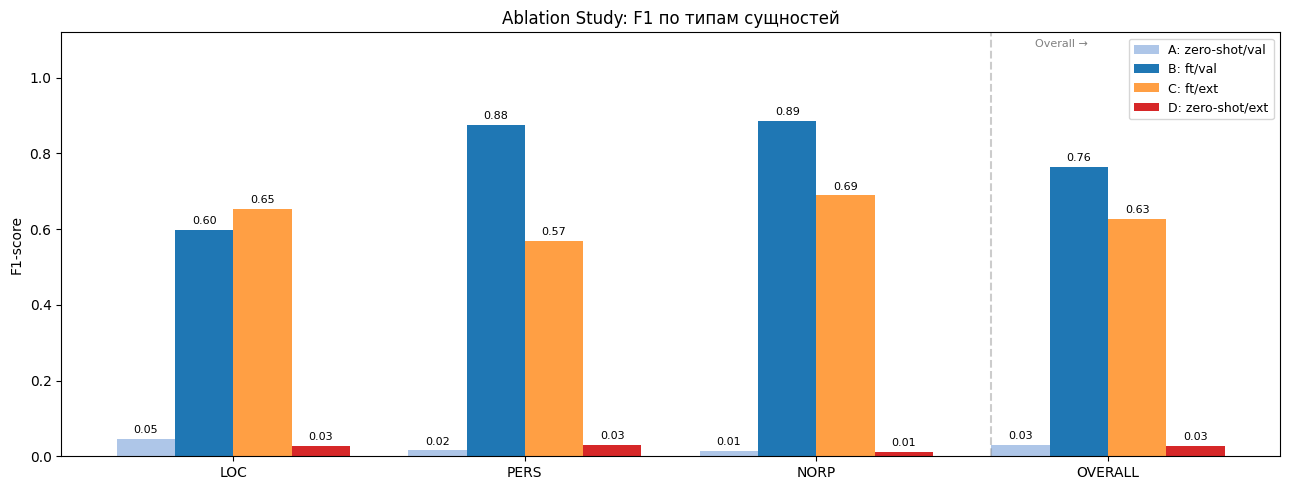

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

labels_plot = ENTITY_TYPES + ['OVERALL']
x = np.arange(len(labels_plot))
width = 0.2

run_labels = ['A: zero-shot/val', 'B: ft/val', 'C: ft/ext', 'D: zero-shot/ext']
run_metrics = [metrics_A_val, metrics_B_val, metrics_B_ext, metrics_A_ext]
colors = ['#aec6e8', '#1f77b4', '#ff9f44', '#d62728']

fig, ax = plt.subplots(figsize=(13, 5))
for i, (name, m, color) in enumerate(zip(run_labels, run_metrics, colors)):
    vals = [m.get(f'{et}_f1') or 0 for et in ENTITY_TYPES] + [m['overall_f1']]
    bars = ax.bar(x + i * width, vals, width, label=name, color=color)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{v:.2f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(labels_plot)
ax.set_ylabel('F1-score')
ax.set_ylim(0, 1.12)
ax.set_title('Ablation Study: F1 по типам сущностей')
ax.legend(loc='upper right', fontsize=9)
ax.axvline(len(ENTITY_TYPES) - 0.1, color='gray', linestyle='--', alpha=0.4)
ax.text(len(ENTITY_TYPES) + 0.05, 1.08, 'Overall ->', fontsize=8, color='gray')
plt.tight_layout()
plt.savefig('ablation_f1.png', dpi=130, bbox_inches='tight')
plt.show()

Calibration: reliability diagrams — 4 модели на одном графике

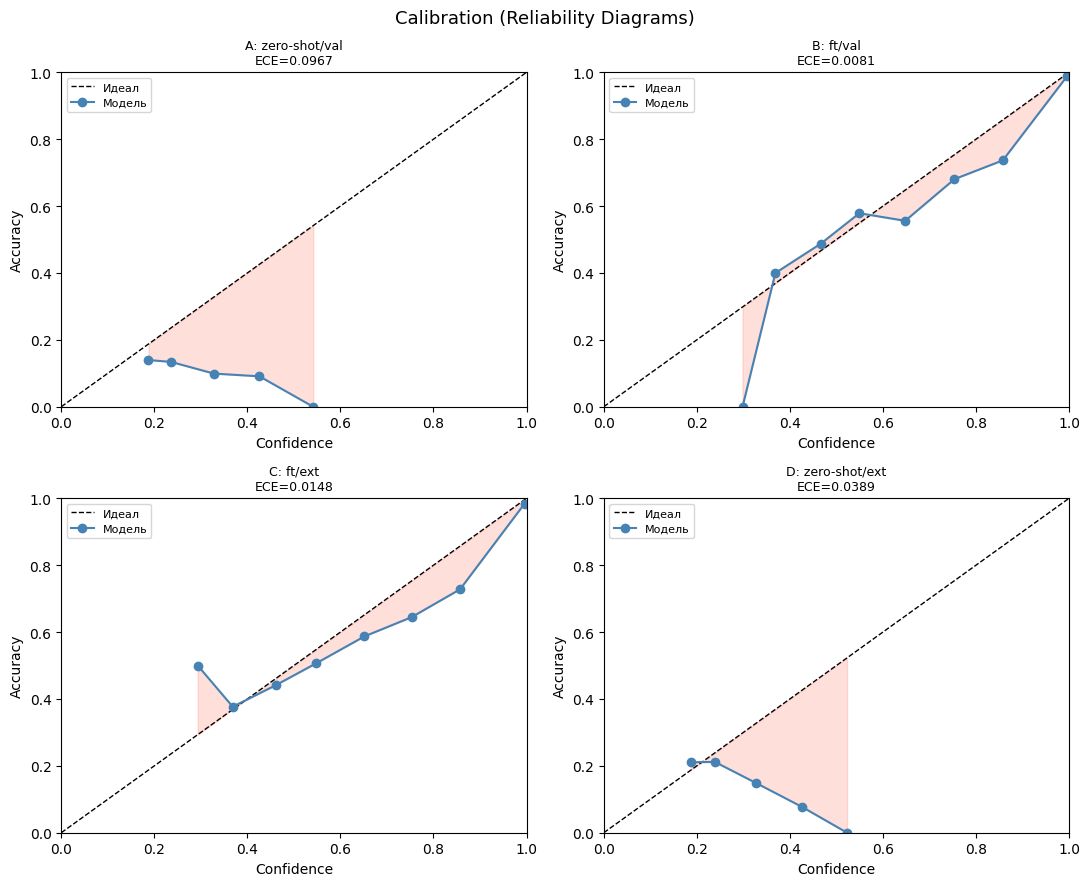

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
fig.suptitle('Calibration (Reliability Diagrams)', fontsize=13)

for ax, (name, m) in zip(axes.flatten(),
                          zip(run_labels, run_metrics)):
    ax.plot([0,1],[0,1],'k--', lw=1, label='Идеал')
    ax.plot(m['bin_conf'], m['bin_acc'], 'o-', color='steelblue', label='Модель')
    ax.fill_between(m['bin_conf'], m['bin_acc'], m['bin_conf'],
                    alpha=0.2, color='tomato')
    ax.set_title(f'{name}\nECE={m["ece"]:.4f}', fontsize=9)
    ax.set_xlim(0,1); ax.set_ylim(0,1)
    ax.set_xlabel('Confidence'); ax.set_ylabel('Accuracy')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('ablation_calibration.png', dpi=130, bbox_inches='tight')
plt.show()

Confusion matrices — 2×2 (val и ext, A и B)

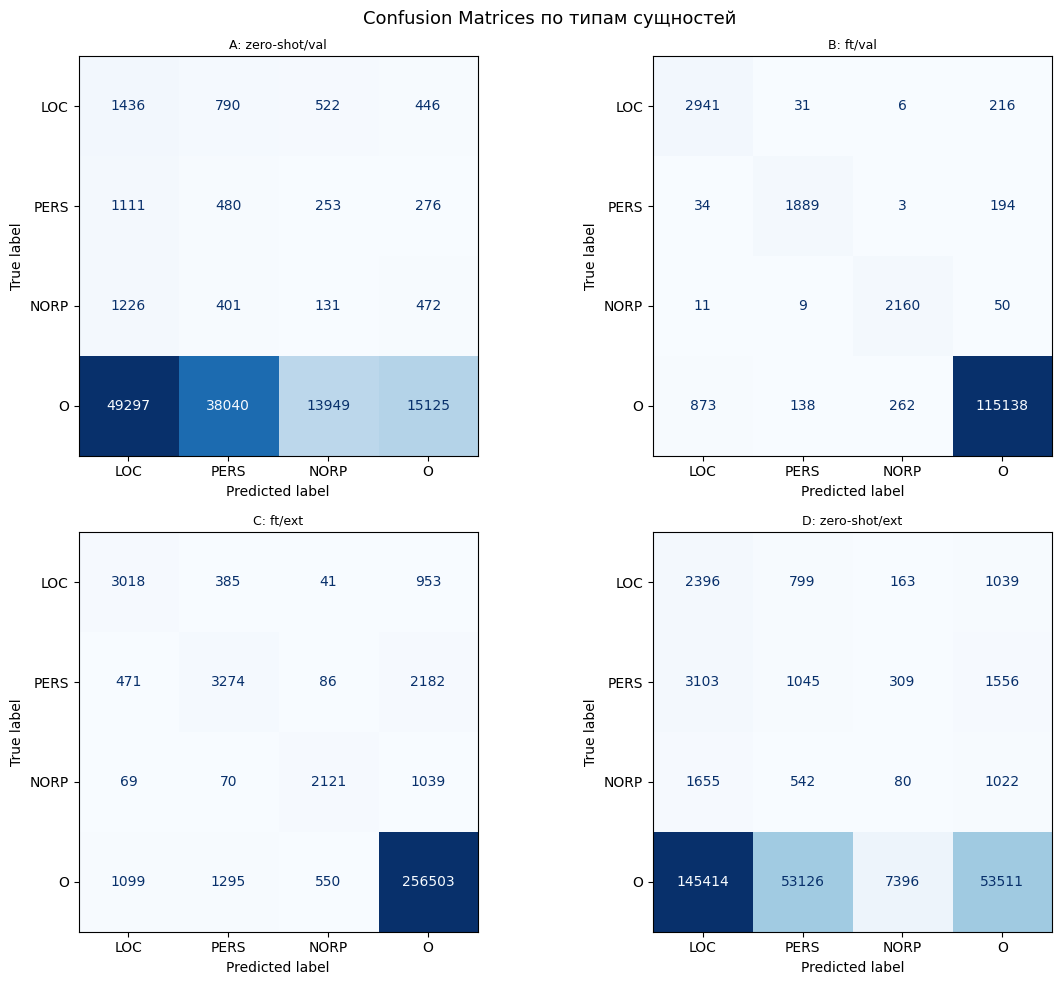

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Confusion Matrices по типам сущностей', fontsize=13)

for ax, (name, m) in zip(axes.flatten(),
                          zip(run_labels, run_metrics)):
    disp = ConfusionMatrixDisplay(confusion_matrix=m['cm'],
                                   display_labels=m['cm_labels'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues', values_format='d')
    ax.set_title(name, fontsize=9)

plt.tight_layout()
plt.savefig('ablation_confusion.png', dpi=130, bbox_inches='tight')
plt.show()

ECR и CUP-UNE: сравнение по наборам данных

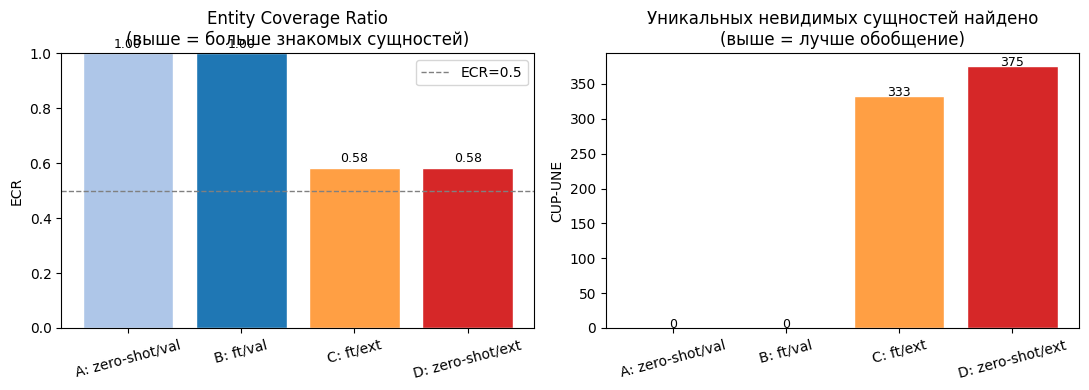

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# ECR
ecr_vals = [metrics_A_val['ecr'], metrics_B_val['ecr'],
             metrics_B_ext['ecr'], metrics_A_ext['ecr']]
colors_bar = ['#aec6e8', '#1f77b4', '#ff9f44', '#d62728']
axes[0].bar(run_labels, ecr_vals, color=colors_bar, edgecolor='white')
axes[0].axhline(0.5, color='gray', linestyle='--', lw=1, label='ECR=0.5')
axes[0].set_ylim(0, 1)
axes[0].set_ylabel('ECR')
axes[0].set_title('Entity Coverage Ratio\n(выше = больше знакомых сущностей)')
axes[0].legend()
for i, v in enumerate(ecr_vals):
    axes[0].text(i, v + 0.02, f'{v:.2f}', ha='center', fontsize=9)

# CUP-UNE
cup_vals = [metrics_A_val['cup_une'], metrics_B_val['cup_une'],
            metrics_B_ext['cup_une'], metrics_A_ext['cup_une']]
axes[1].bar(run_labels, cup_vals, color=colors_bar, edgecolor='white')
axes[1].set_ylabel('CUP-UNE')
axes[1].set_title('Уникальных невидимых сущностей найдено\n(выше = лучше обобщение)')
for i, v in enumerate(cup_vals):
    axes[1].text(i, v + 0.3, str(v), ha='center', fontsize=9)

for ax in axes:
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('ablation_ecr_cup.png', dpi=130, bbox_inches='tight')
plt.show()